In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re

In [4]:
data_root = '/astrum/home/hpchzy/code/data/'

date_base = '20260509'

output = 'output_sampOpt_filtOpt'

kernel = 'jacobi2d5p'

# hostname = 'cgnr6760pn2'
hostname = 'c920bn3'

iarr = 1024

data_path = os.path.join(data_root, f'{date_base}/{hostname}/{output}')

In [5]:
folder_list = glob.glob(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))

tm_total_df = pd.DataFrame()
for folder_path in folder_list:
    res = re.search(f'{kernel}{iarr}.*_(.*)_{hostname}', folder_path)
    timer = res.group(1)

    tf_csv_path = glob.glob(os.path.join(folder_path, 'tf.csv'))
    if not tf_csv_path:
        continue
    tm_df = pd.read_csv(tf_csv_path[0], header=None)
    tm_df.columns = ['ns']
    tm_df['timer'] = timer
    tm_total_df = pd.concat([tm_total_df, tm_df])

tm_total_df.sort_values(by=['timer'], inplace=True)
tm_total_df.reset_index(drop=True, inplace=True)

tm_total_df

,ns,timer
0,2330,cgt
1,3930,cgt
2,5331,cgt
3,4960,cgt
4,5741,cgt
...,...,...
39244795,4470,papix6
39244796,3910,papix6
39244797,4841,papix6
39244798,6101,papix6


In [6]:
thresholds = tm_total_df.groupby('timer')['ns'].quantile(0.995)
tm_filtered = tm_total_df[
    tm_total_df['ns'] <= tm_total_df['timer'].map(thresholds)
]
df_sampled = tm_filtered.sample(n=1000000, random_state=42)

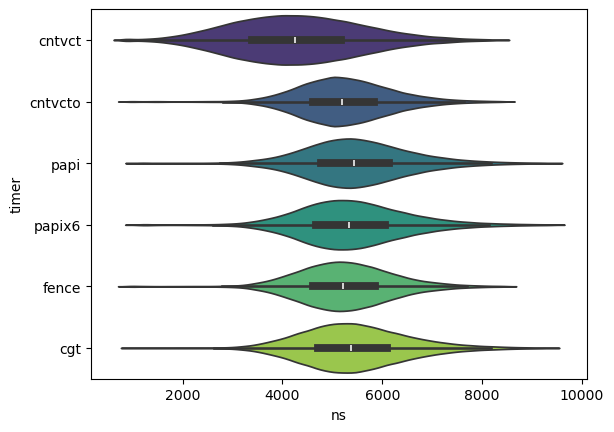

In [7]:
sns.violinplot(data=df_sampled,
    x='ns',
    y='timer',
    hue='timer',
    palette="viridis",
    legend=False)
plt.show()

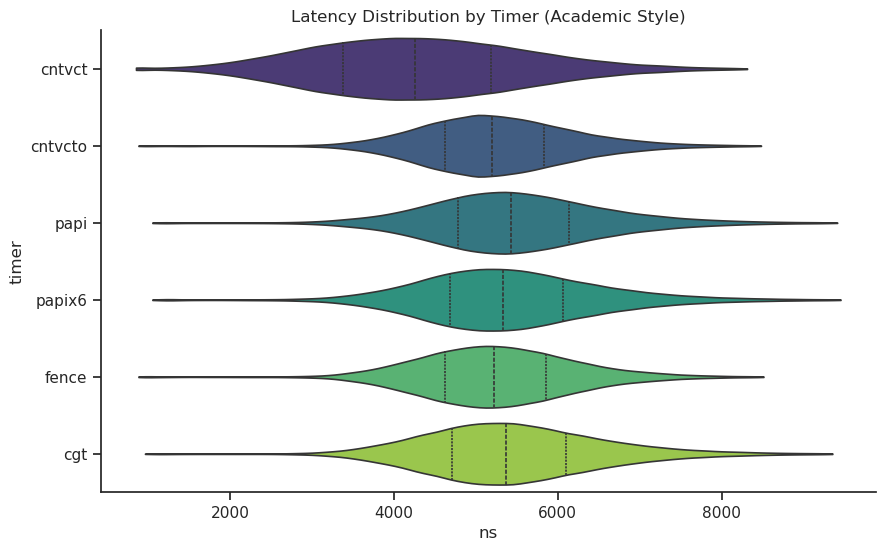

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置主题为白底加刻度
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_sampled, 
    x='ns', y='timer', hue='timer',
    palette="viridis",    # 经典的科学计算配色
    inner="quart",        # 仅显示四分位数虚线，不显示那个粗黑块
    linewidth=1.2,        # 减小线条粗细
    density_norm="width", # 让提琴等宽，方便对比形状
    cut=0                 # 禁止插值到数据范围之外（不产生负数时间）
)

# 移除上侧和右侧的边框线
sns.despine()
plt.title("Latency Distribution by Timer (Academic Style)")
plt.show()